In [6]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten


In [7]:
# preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
    X, y = [], []
    
    for i in range(len(timeseries_data)):
        # find the end of this pattern
        end_ix = i + n_features
        
        # check if we are beyond the sequence
        if end_ix > len(timeseries_data) - 1:
            break
        
        # gather input and output parts of the pattern
        seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    return np.array(X), np.array(y)

In [18]:
timeseries_data = [110,125,134,144,156,163,170,184,195]
n_steps = 3
X,y = prepare_data(timeseries_data,n_steps)

In [19]:
print(X),print(y)

[[110 125 134]
 [125 134 144]
 [134 144 156]
 [144 156 163]
 [156 163 170]
 [163 170 184]]
[144 156 163 170 184 195]


(None, None)

In [20]:
X.shape

(6, 3)

In [21]:
n_features = 1
X = X.reshape((X.shape[0],X.shape[1],n_features))

# because in LSTM MODEL input should be 3 dimention to we convert into 3D 

In [23]:
model = Sequential()
model.add(LSTM(50,activation='relu',return_sequences=True,input_shape = (n_steps,n_features)))
model.add(LSTM(50,activation='relu'))
model.add(Dense(1))
model.compile(optimizer = 'adam',loss='mse')
model.fit(X,y,epochs=250,verbose=1)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 29681.4688
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 29193.6953
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 28736.2910
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 28270.0762
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 27796.1250
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 27335.3750
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 26878.8125
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 26415.8066
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 25945.6270
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 25463.2598
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 24960.1719
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 24415.8770
Epoch 13/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 23805.0625
Epoch 14/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 23145.3848
Epoch 15/250
1/1 ━━━━━━━━━━━━━

In [26]:
 # demonstrate prediction for next 10 days

x_input = np.array([187, 196, 210])
temp_input = list(x_input)
lst_output = []
i = 0

while (i < 10):

    if (len(temp_input) > 3):
        x_input = np.array(temp_input[1:])
        print("{} day input {}".format(i, x_input))

        # print(x_input)
        x_input = x_input.reshape((1, n_steps, n_features))

        # print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i, yhat))

        temp_input.append(yhat[0][0])
        temp_input = temp_input[1:]

        # print(temp_input)
        lst_output.append(yhat[0][0])
        i = i + 1

    else:
        x_input = x_input.reshape((1, n_steps, n_features))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])

        temp_input.append(yhat[0][0])
        lst_output.append(yhat[0][0])
        i = i + 1

print(lst_output)

[218.58434]
1 day input [196.         210.         218.58433533]
1 day output [[229.50793]]
2 day input [210.         218.58433533 229.50793457]
2 day output [[243.27168]]
3 day input [218.58434 229.50793 243.27168]
3 day output [[253.96353]]
4 day input [229.50793 243.27168 253.96353]
4 day output [[266.6514]]
5 day input [243.27168 253.96353 266.6514 ]
5 day output [[281.00482]]
6 day input [253.96353 266.6514  281.00482]
6 day output [[293.80716]]
7 day input [266.6514  281.00482 293.80716]
7 day output [[308.2735]]
8 day input [281.00482 293.80716 308.2735 ]
8 day output [[323.80444]]
9 day input [293.80716 308.2735  323.80444]
9 day output [[338.7858]]
[np.float32(218.58434), np.float32(229.50793), np.float32(243.27168), np.float32(253.96353), np.float32(266.6514), np.float32(281.00482), np.float32(293.80716), np.float32(308.2735), np.float32(323.80444), np.float32(338.7858)]


In [27]:
import matplotlib.pyplot as plt

In [29]:
day_new = np.arange(1,10)
day_pred = np.arange(10,20)

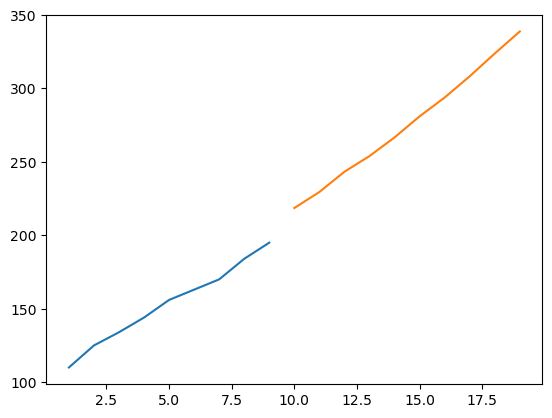

In [30]:
plt.plot(day_new,timeseries_data)
plt.plot(day_pred,lst_output)